# Lecture 3 (19 Sep 2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kosavina/hse-python-2026/blob/main/Lecture_3.ipynb)

**Block 0 — the containers** (Block 2 from Lecture 2)

8. Arguments, defaults, scope
9. `lambda`, `*args`, `**kwargs`
10. Strings and slicing
11. f-strings
12. Lists, tuples, dictionaries, sets

**Block 1 — control flow**

13. Conditions: `if`, `elif`, `else`
14. Loops: `while`, `for`, `break`, `continue`
15. `map`, `filter`, `reduce`
16. Comprehensions
17. `Counter`
18. Exceptions: `try` / `except`


---
---
# Block 0 — the containers (Block 2 from Lecture 2)

A short recap before we start: a **name** is a label on an object, lists are **mutable**, and a function either returns a value or edits its input. Everything in this block is a container, and every container is either mutable or not.

---
## 8 · Arguments, defaults, scope

We did `return` in Lecture 2 (Block 1), so this is about what goes *in*: positional, keyword, default. Then scope — which names a function can see.

### Function Parameters and Arguments

Parameters are variables listed in the function’s definition. Arguments are the values you pass to the function’s parameters.

#### Positional Arguments

In [ ]:
def add(a, b):
    return a + b

result = add(5, 3)
print("The sum is:", result)

#### Keyword Arguments

You can also pass arguments using the key=value syntax.

In [ ]:
def introduce(name, age):
    print(f"My name is {name} and I am {age} years old.")

introduce(age=25, name="Alice")

#### Default Parameters

You can assign default values to parameters.

In [ ]:
def greet(name="Guest"):
    print(f"Hello, {name}!")

greet()


In [ ]:
greet("Bob")

### Mixed parameters/arguments

* Non-default parameters precede default parameters
* Keyword arguments follow positional arguments

In [ ]:
def add(a, b=5):
  return a + b

print(add(10))

### Variable Scope

Scope refers to the visibility of variables. Variables defined inside a function are not visible from outside.

#### Local Variables

In [ ]:
del x

In [ ]:
def func():
    x = 10  # Local variable
    print("Inside function:", x)

func()

In [ ]:
print(x)

#### Global Variables

In [ ]:
x = 20  # Global variable

def func():
    global x
    x = 10
    print("Inside function:", x)

func()
print("Outside function:", x)

---
## 9 · `lambda`, `*args`, `**kwargs`

**Recognition level only.** You need to recognise these when a model writes them for you. You do not need to write them this year.

### Lambda Functions

Lambda functions are small anonymous functions defined with the lambda keyword.

```python
lambda arguments: expression
```

In [ ]:
def multiply(a, b):
  return a * b

In [ ]:
multiply = lambda a, b: a * b
print("Product:", multiply(4, 5))

### Variable-Length Arguments

Sometimes, you may not know in advance how many arguments a function should accept.

#### *args (Non-Keyword Arguments)

In [ ]:
def sum_all(*args):
  total = 0
  for num in args:
      total += num # total = total + num
      print(total)
  return total

print("Sum:", sum_all(1, 2, 3, 4, 5))

#### **kwargs (Keyword Arguments)

In [ ]:
def print_info(**kwargs):
  for key, value in kwargs.items():
      print(f"{key}: {value}")

print_info(name="Alice", age=25, city="New York")

---
## 10 · Strings and slicing

**The section that matters most in Block 0.** `[start:stop]` includes `start` and excludes `stop`. Every off-by-one you will ever meet lives in that sentence.

### Compound types: Strings, List and dictionaries

[Data Structures](https://docs.python.org/3/tutorial/datastructures.html)


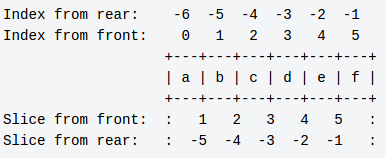

In [ ]:
a = ['a', 'b', 'c', 'd', 'e', 'f']

[begin: end: (direction)step]

In [ ]:
a[3::-1]

### Strings

[Docs](https://docs.python.org/3/library/stdtypes.html#text-sequence-type-str
)

Strings are the variable type that is used for storing text messages.

In [ ]:
s = 'as"d'
print(s)
s = "a'sd"
print(s)

In [ ]:
s = '''sdfsdfsdf
fsdfsdf
sdfsdfs
sdfsdfsdf
'''
print(s)

In [ ]:
s = "Hello world"
type(s)

In [ ]:
s = 'asd'
s.center(20, 't')

In [ ]:
# length of the string: the number of characters
len(s)

In [ ]:
help(len)

In [ ]:
# replace a substring in a string with something else
s = "Hello world Hello world"

s2 = s.replace("world", "test", 2)
print(s2)

We can index a character in a string using `[]`:

In [ ]:
s = "Hello world"

In [ ]:
s[0]

**Heads up MATLAB users:** Indexing start at 0!

We can extract a part of a string using the syntax `[start:stop]`, which extracts characters between index `start` and `stop` -1 (the character at index `stop` is not included):

In [ ]:
s[0:5]

In [ ]:
s[4:5]

If we omit either (or both) of `start` or `stop` from `[start:stop]`, the default is the beginning and the end of the string, respectively:

In [ ]:
s[:5]

In [ ]:
s[6:]

In [ ]:
s[:]

We can also define the step size using the syntax `[start:end:step]` (the default value for `step` is 1, as we saw above):

In [ ]:
s[::1]

In [ ]:
s[::2]

In [ ]:
s = 'abcdef'
s[4::-1]

This technique is called *slicing*. Read more about the syntax here: https://docs.python.org/3/library/functions.html#slice

Python has a very rich set of functions for text processing. See for example https://docs.python.org/3/library/string.html for more information.

### The half-open rule, stated once

`s[a:b]` gives you the characters from position `a` **up to but not including** `b`.

Two consequences worth memorising:

- `len(s[a:b])` is `b - a`. Always. That is *why* the rule exists.
- `s[:k]` and `s[k:]` fit together perfectly, with no gap and no overlap, for any `k`.

Python counts from 0 and excludes the end. Almost every other convention you have met in finance — quarters, months, "the first five days" — counts from 1 and includes the end. Converting between the two, in your head, at speed, is the single most common way to be off by one.

---
## 11 · f-strings

The 2025 notebook teaches `%` and `.format()`. Both still work and you will see them in older code. Neither is what you should write.

Put an `f` in front of the quote, and anything inside `{ }` is evaluated as Python and dropped into the string.

In [ ]:
ticker = "SBER"
close  = 299.9
ret    = 0.1015610651974288

print(f"{ticker} closed at {close}")
print(f"{ticker} returned {ret} over the year")

The second line is unreadable. A colon inside the braces says **how** to format the value:

In [ ]:
print(f"{ret:.2%}")        # as a percentage, 2 decimals
print(f"{ret:.4f}")        # as a decimal, 4 places
print(f"{close:10.2f}")    # right-aligned in a field 10 wide
print(f"{close:,.2f}")     # thousands separator
print(f"{ticker:>8} | {close:>8.2f} | {ret:>7.2%}")   # a table row

`{ret:.2%}` multiplies by 100 **and** adds the `%` sign. This is a real source of the percent-versus-decimal error: if you write `f"{ret*100:.2%}"` you get `1015.61%`, and the code runs perfectly.

Finally, `=` inside the braces prints the expression *and* its value — the fastest debugging tool in the language:

In [ ]:
n_days = 254
print(f"{n_days=}")
print(f"{n_days / 12 = :.1f}")

---
## 12 · Lists, tuples, dictionaries, sets

Four containers. The question to ask about each one: **can I change it after I make it, and what can I look things up by?**

### List

[Docs](https://docs.python.org/3/library/stdtypes.html#list)

Lists are very similar to strings, except that each element can be of any type.

The syntax for creating lists in Python is `[...]`:

In [ ]:
l = [1, 2, 3, 4]

print(type(l))
print(l)

We can use the same slicing techniques to manipulate lists as we could use on strings:


In [ ]:
print(l)

print(l[1:3])

print(l[::2])

**Heads up MATLAB users:** Indexing starts at 0!

In [ ]:
l[0]

Elements in a list do not all have to be of the same type:

In [ ]:
l = [1, 'a', 1.0, 1-1j]

print(l)

Python lists can be inhomogeneous and arbitrarily nested:

In [ ]:
nested_list = [1, [2, [3, [4, [5]]]]]
print(nested_list[1][1][1][1][0])


Lists play a very important role in Python. For example they are used in loops and other flow control structures (discussed below). There are a number of convenient functions for generating lists of various types, for example the `range` function:

In [ ]:
start = 10
stop = 30
step = 2

list(range(start, stop, step))

In [ ]:
# in python 3 range generates an iterator, which can be converted to a list using 'list(...)'.
# It has no effect in python 2
list(range(start, stop, step))

In [ ]:
list(range(-10, 10))

In [ ]:
s = 'abcdef'

In [ ]:
# convert a string to a list by type casting:
s2 = list(s)

s2

In [ ]:
s2 = [1, 5, 9, 2, 4, 7]
print(s2)

In [ ]:
w = sorted(s2)

In [ ]:
type(w)

In [ ]:
# sorting lists
s2.sort()

print(s2)

#### Adding, inserting, modifying, and removing elements from lists

We can modify lists by assigning new values to elements in the list. In technical jargon, lists are *mutable*.

In [ ]:
l[1:3] = ["d", "d"]

print(l)

Insert an element at an specific index using `insert`

In [ ]:
l.insert(0, "i")
l.insert(1, "n")
l.insert(2, "s")
l.insert(3, "e")
l.insert(4, "r")
l.insert(22, "t")

print(l)

Remove first element with specific value using 'remove'

In [ ]:
l.remove("t")

print(l)

Remove an element at a specific location using `del`:

In [ ]:
del l[7]
del l[6]

print(l)

See `help(list)` for more details, or read the online documentation

### Tuples

[Docs](https://docs.python.org/3/library/stdtypes.html#tuple)

Tuples are like lists, except that they cannot be modified once created, that is they are *immutable*.

In Python, tuples are created using the syntax `(..., ..., ...)`, or even `..., ...`:

In [ ]:
point = (10, 20)

print(point, type(point))

In [ ]:
point = 10, 20

print(point, type(point))

We can unpack a tuple by assigning it to a comma-separated list of variables:

In [ ]:
x, y = point

print("x =", x)
print("y =", y)

If we try to assign a new value to an element in a tuple we get an error:

> ⚠️ **This cell is supposed to raise an error.** That is the lesson. Run it, read the error type and the message, and move on — nothing is broken.

In [ ]:
point[0] = 20

### Dictionaries

[Docs](https://docs.python.org/3/library/stdtypes.html#mapping-types-dict)

Dictionaries are also like lists, except that each element is a key-value pair. The syntax for dictionaries is `{key1 : value1, ...}`:

In [ ]:
l = [1., 2., 3.]

In [ ]:
l[0]

In [ ]:
params = {"parameter1" : 1.0,
          "parameter2" : 2.0,
          "parameter3" : 3.0,}

print(type(params))
print(params)

In [ ]:
params[(1, 2, 3)] = 'ccc'

In [ ]:
params[[1, 2, 3, 4]] = 'qqwewe'

In [ ]:
print("parameter1 = " + str(params["parameter1"]))
print("parameter2 = " + str(params["parameter2"]))
print("parameter3 = " + str(params["parameter3"]))

In [ ]:
params["parameter1"] = "A"
params["parameter2"] = "B"

# add a new entry
params["parameter4"] = "D"

print("parameter1 = " + str(params["parameter1"]))
print("parameter2 = " + str(params["parameter2"]))
print("parameter3 = " + str(params["parameter3"]))
print("parameter4 = " + str(params["parameter4"]))

### Sets

[Docs](https://docs.python.org/3/library/stdtypes.html#set)

In [ ]:
x = ['apple', 'orange', 'apple', 'pear', 'orange', 'banana']

In [ ]:
len(x)

In [ ]:
x[2]

In [ ]:
basket = {'apple', 'orange', 'apple', 'pear', 'orange', 'banana'}
print(basket)                      # show that duplicates have been removed

In [ ]:
len(basket)

In [ ]:
'orange' in basket                 # fast membership testing
# 'crabgrass' in basket

In [ ]:
a = set('abracadabra')
b = set('alacazam')
a                                  # unique letters in a

In [ ]:
a - b                              # letters in a but not in b

In [ ]:
a | b                             # letters in a or b or both

In [ ]:
a & b                              # letters in both a and b

### Choosing a container

| | ordered? | mutable? | good for |
|---|---|---|---|
| `list` | yes | **yes** | a sequence you will add to or change — prices, dates, rows |
| `tuple` | yes | no | a fixed record that should not change — a coordinate, a returned pair |
| `dict` | yes (insertion) | **yes** | lookup by a key — ticker → price, month → average |
| `set` | no | **yes** | membership tests and removing duplicates |

---
---
# Block 1 — control flow

So far every cell ran top to bottom, once. Block 1 is about code that decides (`if`), repeats (`for`, `while`) and recovers when something goes wrong (`try`). This is most of what an AI-written analysis script is made of.

---
## 13 · Conditions: `if`, `elif`, `else`

A condition is any expression Python can read as `True` or `False`. Watch which values count as "false": `0`, `""`, `[]`, `None`.

Conditional statements allow your program to execute certain pieces of code based on specific conditions.

| Precedence | Operator | Description | Associativity |
|------------|----------|-------------|---------------|
| 1 (Highest) | () | Parentheses | N/A |
| 2 | ** | Exponentiation | Right-to-left |
| 3 | +x, -x, ~x | Unary plus, unary minus, bitwise NOT | Right-to-left |
| 4 | *, /, //, % | Multiplication, division, floor division, modulo | Left-to-right |
| 5 | +, - | Addition, subtraction | Left-to-right |
| 6 | <<, >> | Bitwise left shift, right shift | Left-to-right |
| 7 | & | Bitwise AND | Left-to-right |
| 8 | ^ | Bitwise XOR | Left-to-right |
| 9 | \| | Bitwise OR | Left-to-right |
| 10 | in, not in, is, is not, <, <=, >, >=, !=, == | Comparison operators, membership, identity | Left-to-right |
| 11 | not | Logical NOT | Right-to-left |
| 12 | and | Logical AND | Left-to-right |
| 13 | or | Logical OR | Left-to-right |
| 14 | := | Walrus (assignment expression) | Right-to-left |
| 15 | if-else | Conditional expression (e.g., x if condition else y) | Right-to-left |
| 16 | lambda | Lambda expression | Right-to-left |
| 17 (Lowest) | = | Assignment (and augmented assignments like +=, -=, etc.) | Right-to-left |

### If Statements

The if statement is used to test a condition. If the condition is True, the indented block of code under the if statement gets executed.

In Python, several values evaluate to True when used in a conditional context. Here are some key cases:

1. Non-zero Numbers: Any integer or float that is not zero (1, -1, 3.14, etc.)
2. Non-empty Strings: Any string with at least one character ("Hello", " "), except the empty string ""
3. Non-empty Data Structures: Lists, dictionaries, tuples, and sets with at least one element ([1], {0: "value"}, ("a",), {1})
4. Custom Objects: Any instance of a class, unless it has a __bool__ or __len__ method that returns False or zero
5. True: The Boolean literal True itself
6. Non-None Values: Any object that isn’t explicitly None (such as instances of classes, functions, and other data types)

These values will make a conditional statement like if <value>: execute the block because they are truthy.

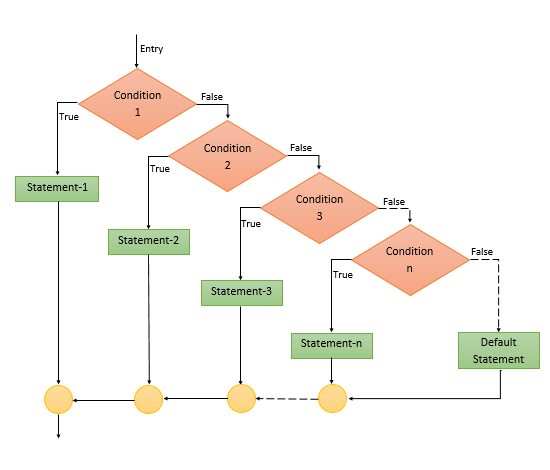

```python
if condition:
    # Code to execute if condition is True
```

In [ ]:
age = 18

if age >= 18:
    print("You are eligible to vote.")

### Else Statements

The else statement can be used to execute code when the if condition is False.

```python
if condition:
    # Code if condition is True
else:
    # Code if condition is False
```

In [ ]:
age = 16

if age >= 18:
    print("You are eligible to vote.")
else:
    print("You are not eligible to vote.")

### Elif Statements

The elif (short for “else if”) statement allows you to check multiple conditions.

```python
if condition1:
    # Code if condition1 is True
elif condition2:
    # Code if condition2 is True
else:
    # Code if all conditions are False
```

In [ ]:
score = 85

if score >= 90:
    print("Grade: A")
elif score >= 80:
    print("Grade: B")
else:
    print("Grade: C")

### Nested Conditions
You can have conditions within conditions.

In [ ]:
num = 10

if num > 0:
    print("Positive number")
    if num % 2 == 0:
        print("Even number")
    else:
        print("Odd number")
else:
    print("Negative number")

### The ternary conditional operator

```python
value_if_true if condition else value_if_false
```

In [ ]:
x = 10
result = "Positive" if x > 0 else "Non-positive"
print(result)

### Logical Operators

Logical operators allow you to combine multiple conditions.

* and: True if both conditions are True
* or: True if at least one condition is True
* not: Inverts the truth value

In [ ]:
age = 25
income = 50000

if age >= 18 and income >= 30000:
    print("You are eligible for a credit card.")

---
## 14 · Loops: `while`, `for`, `break`, `continue`

`for` walks over a container; `while` repeats until a condition turns false. `range(n)` is half-open, like slicing: `0, 1, …, n-1`.

Loops are used to execute a block of code repeatedly.

### While Loops

A while loop executes as long as a specified condition is True.

```python
while condition:
    # Code to execute repeatedly
```

In [ ]:
count = 1

while count <= 5:
    print("Count:", count)
    count += 1

### For Loops

A for loop is used for iterating over a sequence (like a list, tuple, dictionary, set, or string).

```python
for variable in sequence:
    # Code to execute repeatedly
```

In [ ]:
fruits = ["apple", "banana", "cherry"]

for i in fruits:
    print("I like", i)

### Using range() Function

In [ ]:
for i in range(5):
    print("Number:", i)

### Loop Control Statements

Control statements change the execution flow of loops.

#### Break Statement

Exits the loop immediately.

In [ ]:
for i in range(1, 11):
    if i == 5:
        break
    print(i)

In [ ]:
%%timeit

for i in range(int(1.e+8)):
  break

In [ ]:
%%timeit

for i in list(range(int(1.e+8))):
  break

#### Continue Statement

Skips the current iteration and continues with the next.

In [ ]:
for i in range(1, 6):
    if i == 3:
        continue
    print(i)

#### Pass Statement

Does nothing; it acts as a placeholder.

In [ ]:
for i in range(5):
    pass  # To be implemented later

#### else Clauses on Loops

In a for or while loop the break statement may be paired with an else clause. If the loop finishes without executing the break, the else clause executes.

In a for loop, the else clause is executed after the loop finishes its final iteration, that is, if no break occurred.

In a while loop, it’s executed after the loop’s condition becomes false.

In either kind of loop, the else clause is not executed if the loop was terminated by a break. Of course, other ways of ending the loop early, such as a return or a raised exception, will also skip execution of the else clause.

```python
numbers = [-3, -1, 4, -2, 6, 7, -5]

for num in numbers:
    if num < 0:  # Skip negative numbers
        print(f"Skipping {num} (negative)")
        continue
    if num % 2 == 0:  # Found a positive even number
        print(f"Found positive even number: {num}")
        break
    print(f"Checking {num} (not even)")
else:
    print("No positive even number found")
```

---
## 15 · `map`, `filter`, `reduce`

**Recognition level only.** You need to recognise these when a model writes them for you. You do not need to write them this year: a comprehension (section 16) usually reads better.

### Overview

* map(): Applies a function to every item of an iterable (e.g., list, tuple) and returns a map object (an iterator).
* filter(): Constructs an iterator from elements of an iterable for which a function returns true.
* reduce(): Applies a function of two arguments cumulatively to the items of an iterable, reducing the iterable to a single value.

### map() Function

The map() function allows you to apply a function to all the items in an input list or iterable.

```python
map(function, iterable)
```

* function: The function to apply to each item.
* iterable: The iterable whose items you want to process.

Returns a map object (which is an iterator) containing the results.

In [ ]:
def square(y):
    return y * y

numbers = [1, 2, 3, 4, 5]
squared_numbers = map(square, numbers)
print(squared_numbers)
print(list(squared_numbers))

In [ ]:
numbers = [1, 2, 3, 4, 5]
squared_numbers = map(lambda x: x * x, numbers)

print(list(squared_numbers))

You can pass multiple iterables to map() if the function accepts multiple arguments.

In [ ]:
numbers1 = [1, 2, 3]
numbers2 = [4, 5, 6]
sum_numbers = map(lambda x, y: x + y, numbers1, numbers2)

print(list(sum_numbers))

### filter() Function

The filter() function constructs an iterator from elements of an iterable for which a function returns True.

```python
filter(function, iterable)
```
* function: A function that returns a boolean value (True or False).
* iterable: The iterable to be filtered.

function: A function that returns a boolean value (True or False).
	•	iterable: The iterable to be filtered.

In [ ]:
def is_even(number):
    return number % 2 == 0

numbers = [1, 2, 3, 4, 5]
even_numbers = filter(is_even, numbers)

print(list(even_numbers))

In [ ]:
numbers = [1, 2, 3, 4, 5]
odd_numbers = filter(lambda x: x % 2 != 0, numbers)

print(list(odd_numbers))

### reduce() Function

The reduce() function applies a function of two arguments cumulatively to the items of an iterable, reducing the iterable to a single value.

```python
from functools import reduce
reduce(function, iterable[, initializer])
```

* function: A function of two arguments.
* iterable: The iterable to be reduced.
* initializer (optional): A value to start the accumulation.

Returns a single value.

In [ ]:
from functools import reduce

numbers = [1, 2, 3, 4, 5]
sum_numbers = reduce(lambda x, y: x + y, numbers)

print(sum_numbers)

In [ ]:
from functools import reduce

numbers = [5, 2, 8, 1, 9]
max_number = reduce(lambda x, y: x if x > y else y, numbers)

print(max_number)

### Combining map(), filter(), and reduce()

You can combine these functions to perform complex data processing tasks.

Example: Sum of Squares of Even Numbers

Let’s find the sum of the squares of even numbers in a list.

In [ ]:
from functools import reduce

numbers = [1, 2, 3, 4, 5, 6]

# Step 1: Filter even numbers
even_numbers = filter(lambda x: x % 2 == 0, numbers)
even_numbers = list(even_numbers)
print(even_numbers)

# Step 2: Square each even number
squared_even_numbers = map(lambda x: x * x, even_numbers)
# print(list(squared_even_numbers))

# Step 3: Sum the squared even numbers
sum_of_squares = reduce(lambda x, y: x + y, squared_even_numbers)
print(sum_of_squares)

---
## 16 · Comprehensions

One line that builds a list, dict or set from a loop. Models write these constantly, so read each one back as the `for` loop it replaces.

Comprehensions in Python offer a concise way to create collections like lists, tuples, dictionaries, and sets by applying expressions to each item in an iterable. Here’s a breakdown of each type with examples:

### List Comprehension

A list comprehension generates a new list by transforming elements in an existing iterable, typically with a single line of code.

``` python
[expression for item in iterable if condition]
```

In [ ]:
numbers = [1, 2, 3, 4, 5]
squares = [x**2 for x in numbers]
# Output: [1, 4, 9, 16, 25]

In [ ]:
even_squares = [x**2 for x in numbers if x % 2 == 0]
# Output: [4, 16]
print(even_squares)

### Tuple Comprehension (using tuple() with generator expressions)

Python doesn’t have a dedicated tuple comprehension; instead, we use a generator expression inside the tuple() function to create a tuple.

``` python
tuple(expression for item in iterable if condition)
```

In [ ]:
numbers = [1, 2, 2, 3, 4, 4, 5]
squared_tuple = tuple(x**2 for x in numbers)
print(squared_tuple)
# Output: (1, 4, 9, 16, 25)

### Dictionary Comprehension

Dictionary comprehension is a way to construct dictionaries by specifying both keys and values.

``` python
{key_expression: value_expression for item in iterable if condition}
```

In [ ]:
words = ["apple", "banana", "cherry"]
word_lengths = {x: len(x) for x in words}
# Output: {'apple': 5, 'banana': 6, 'cherry': 6}
print(word_lengths)

In [ ]:
numbers = [1, 2, 2, 3, 4, 4, 5]
square_dict = {x: x**2 for x in numbers if x % 2 == 0}
print(square_dict)
# Output: {2: 4, 4: 16}

### Set Comprehension

A set comprehension generates a set by applying an expression to each item in an iterable. It follows the same syntax as list comprehension but uses curly braces {}.

``` python
{expression for item in iterable if condition}
```

In [ ]:
numbers = [1, 2, 2, 3, 4, 4, 5]
unique_squares = {x**2 for x in numbers}
# Output: {1, 4, 9, 16, 25}

In [ ]:
even_squares = {x**2 for x in numbers if x % 2 == 0}
# Output: {4, 16}

Summary

* List Comprehension:
``` python
[expression for item in iterable if condition]
```
* Tuple Comprehension:
``` python
tuple(expression for item in iterable if condition)
```
* Dictionary Comprehension:
``` python
{key_expression: value_expression for item in iterable if condition}
```
* Set Comprehension:
``` python
{expression for item in iterable if condition}
```

These comprehensions provide a clear, concise, and often more readable way to build collections in Python.

---
## 17 · `Counter`

A dictionary that counts. The quickest answer to "how many of each?".

### Counter object

The Counter class in Python’s collections module is a specialized dictionary subclass for counting hashable objects. It’s ideal for tallying occurrences in iterables like lists, strings, or tuples.

In [ ]:
from collections import Counter

In [ ]:
items = ['apple', 'banana', 'apple', 'orange', 'banana']
counter = Counter(items)
print(counter)

In [ ]:
print(counter['apple'])
print(counter['grape'])

In [ ]:
counter.most_common(1)

In [ ]:
list(counter.elements())

In [ ]:
counter.update(items)

In [ ]:
print(counter)

---
## 18 · Exceptions: `try` / `except`

An exception is Python refusing to continue. `try` / `except` lets you decide what happens instead — and a bare `except:` hides every error, including the ones you did not expect.

In Python, try...except...finally...else is a construct used to handle exceptions, execute cleanup actions, and specify code that should run only if no exceptions occur. Here’s a breakdown of how each part works together:

``` python
try:
    # Code that might raise an exception
except SomeException:
    # Code that runs if a specific exception occurs
else:
    # Code that runs only if no exceptions occur in the try block
finally:
    # Code that always runs, regardless of an exception
```

* **try** Block: The code in this block is executed first. If an exception occurs, the rest of the try block is skipped, and control is passed to the except block. If no exception occurs, control passes to the else block.
* **except** Block: This block catches and handles specific exceptions. If an exception matching the one specified in except is raised in the try block, the except block runs. If no exception occurs, except is skipped.
* **else** Block: The else block runs only if no exceptions are raised in the try block. This is useful for code that should only execute if the try block was successful.
* **finally** Block: The finally block always executes, regardless of whether an exception was raised or not. It’s often used for cleanup actions (e.g., closing files or network connections).

In [ ]:
def divide_numbers(a, b):
  return a / b

> ⚠️ **This cell is supposed to raise an error.** That is the lesson. Run it, read the error type and the message, and move on — nothing is broken.

In [ ]:
divide_numbers(6, 0)

In [ ]:
def divide_numbers(a, b):
    try:
        result = a / b
    except:
        print("Error: Division by zero is not allowed.")
    else:
        print("Division successful. The result is:", result)
    finally:
        print("Execution of the finally block: Clean up resources if needed.")

In [ ]:
divide_numbers(10, 2)  # This should complete successfully and run the else block

In [ ]:
divide_numbers(10, 0)  # This  raise an exception and skip the else block